# Generation of graph data from existing graphs

In [1]:
import geopandas as gpd
from shapely.geometry import LineString, MultiLineString
import networkx as nx
import matplotlib.pyplot as plt
import os
import pickle

## Creating a graph from the fracture network 

In [2]:
print(os.getcwd())

C:\Users\burgoaa\Desktop\python\frac_deepgen


In [3]:
# Read fracture interpretation and transform to graphs
graphs = []
folder = 'data/shapefile'
files = sorted(f for f in os.listdir(folder) if f.endswith('.shp'))
precision = 5 #decimals

for f_name in files:
    print(f_name)
    gdf = gpd.read_file (os.path.join(folder, f_name))
    G = nx.Graph()
    coord_to_label = {}
    label_counter = 0
    edges = []

    for geom in gdf.geometry:
        if isinstance(geom, LineString):
            lines = [geom]
        elif isinstance(geom, MultiLineString):
            lines = list(geom.geoms)
        else:
            continue

        for line in lines:
            coords = [tuple(round(c, precision) for c in pt) for pt in line.coords]
            labels = []

        for coord in coords:
            if coord not in coord_to_label:
                coord_to_label[coord] = label_counter
                x, y = coord[:2]
                G.add_node(label_counter, pos=(x,y))
                label_counter += 1
            labels.append(coord_to_label[coord])

        edges.extend(zip(labels[:-1], labels[1:]))
    
    G.add_edges_from(edges)
    G.remove_edges_from(nx.selfloop_edges(G))
    pos = nx.get_node_attributes(G, 'pos')
    graphs.append(G)

Area1.shp
Area2.shp
Area3.shp
Area4.shp
Area5.shp
Coastal_Bedrock_Geology_snp.shp
Flato_20m_1.shp
Getaberget_20m_1.shp
Getaberget_20m_2_1.shp
Getaberget_20m_2_2.shp
Getaberget_20m_3_3.shp
Getaberget_20m_4_1.shp
Getaberget_20m_4_2.shp
Getaberget_20m_5.shp
Getaberget_20m_7_1.shp
Getaberget_20m_7_2.shp
Getaberget_20m_8.shp
Getaberget_20m_9.shp
Havsvidden_20m.shp
Manual_NE1.shp
Manual_NE2.shp
Manual_SW1.shp
Manual_SW2.shp
Manual_SW3.shp
Mineral_mtns.shp
North.shp
Segelskar_20m_1.shp
Shapefile_South.shp
South_1.shp
Station_Mid1.shp
Station_Mid2.shp
Station_Mid3.shp
Station_North1.shp
Station_South1.shp
Station_South2.shp
Station_South3.shp
apodi2.shp
apodi3.shp
apodi4.shp
braided.shp
brick.shp
diamond.shp
dix-sept1.shp
en_north.shp
en_south.shp
frac_graph_1000.shp
fractures.shp
fractures_projected_snp.shp
hexagonon.shp
hhs.shp
inv.shp
off_sebrazil.shp
out_braided.shp
out_brick.shp
out_diamond.shp
out_hexagonon.shp
out_pavement.shp
out_polygonal.shp
out_square.shp
out_star.shp
out_stochastic

In [4]:
print(graphs[10].nodes(data=True))

[(0, {'pos': (104861.23561, 6719696.27875)}), (1, {'pos': (104860.69761, 6719696.4917)}), (2, {'pos': (104855.93265, 6719695.64547)}), (3, {'pos': (104855.75052, 6719695.20975)}), (4, {'pos': (104848.46876, 6719690.97022)}), (5, {'pos': (104848.27313, 6719690.73901)}), (6, {'pos': (104847.67909, 6719690.4546)}), (7, {'pos': (104847.58942, 6719690.26405)}), (8, {'pos': (104845.55791, 6719688.72711)}), (9, {'pos': (104845.78628, 6719688.83359)}), (10, {'pos': (104843.62867, 6719688.43709)}), (11, {'pos': (104843.78699, 6719688.45811)}), (12, {'pos': (104862.2857, 6719699.28539)}), (13, {'pos': (104862.34945, 6719699.93407)}), (14, {'pos': (104852.74247, 6719686.73342)}), (15, {'pos': (104852.5155, 6719686.54568)}), (16, {'pos': (104858.42532, 6719680.0587)}), (17, {'pos': (104858.23387, 6719680.09456)}), (18, {'pos': (104866.58011, 6719692.73971)}), (19, {'pos': (104866.39749, 6719692.54606)}), (20, {'pos': (104864.02299, 6719694.44548)}), (21, {'pos': (104863.85067, 6719694.33339)}), (2

In [24]:
#Export graph as pickle with attributes
for i, graph in enumerate(graphs):
    output = f'data/tds_rev/G{i}.pickle'
    with open (output, 'wb') as f:
        pickle.dump(graph, f)

In [5]:
# Identify largest connected components from simplified graphs
largest = []
for graph in graphs:
    print(graph)
    all_components = list(nx.connected_components(graph))
    components_sorted = sorted(all_components, key=len, reverse=True)

    for i, comp_nodes in enumerate(components_sorted[:2], start=1):
        Gc = graph.subgraph(comp_nodes).copy()
            
        if Gc.number_of_nodes() >= 30:
            largest.append(Gc)
            print(f'Largest CC:{Gc}')

        else:
            print('Very Small')

Graph with 30299 nodes and 42301 edges
Largest CC:Graph with 28122 nodes and 39314 edges
Largest CC:Graph with 2177 nodes and 2987 edges
Graph with 228661 nodes and 364703 edges
Largest CC:Graph with 228653 nodes and 364699 edges
Very Small
Graph with 26371 nodes and 40243 edges
Largest CC:Graph with 21029 nodes and 32223 edges
Largest CC:Graph with 4359 nodes and 6603 edges
Graph with 235088 nodes and 365332 edges
Largest CC:Graph with 235088 nodes and 365332 edges
Graph with 49771 nodes and 78151 edges
Largest CC:Graph with 49771 nodes and 78151 edges
Graph with 4255 nodes and 3754 edges
Largest CC:Graph with 151 nodes and 150 edges
Largest CC:Graph with 137 nodes and 136 edges
Graph with 4303 nodes and 3694 edges
Largest CC:Graph with 120 nodes and 119 edges
Largest CC:Graph with 108 nodes and 107 edges
Graph with 40347 nodes and 34928 edges
Largest CC:Graph with 415 nodes and 414 edges
Largest CC:Graph with 260 nodes and 259 edges
Graph with 9954 nodes and 8617 edges
Largest CC:Gra

In [28]:
#Export graph as pickle with attributes
for i, graph in enumerate(largest):
    output = f'data/tds_cc/G{i}.pickle'
    with open (output, 'wb') as f:
        pickle.dump(graph, f)

In [6]:
def graph_area(G):
    pos = nx.get_node_attributes(G, 'pos')
    xs = [p[0] for p in pos.values()]
    ys = [p[1] for p in pos.values()]

    width = max(xs) - min(xs)
    height = max(ys) - min(ys)

    return width*height

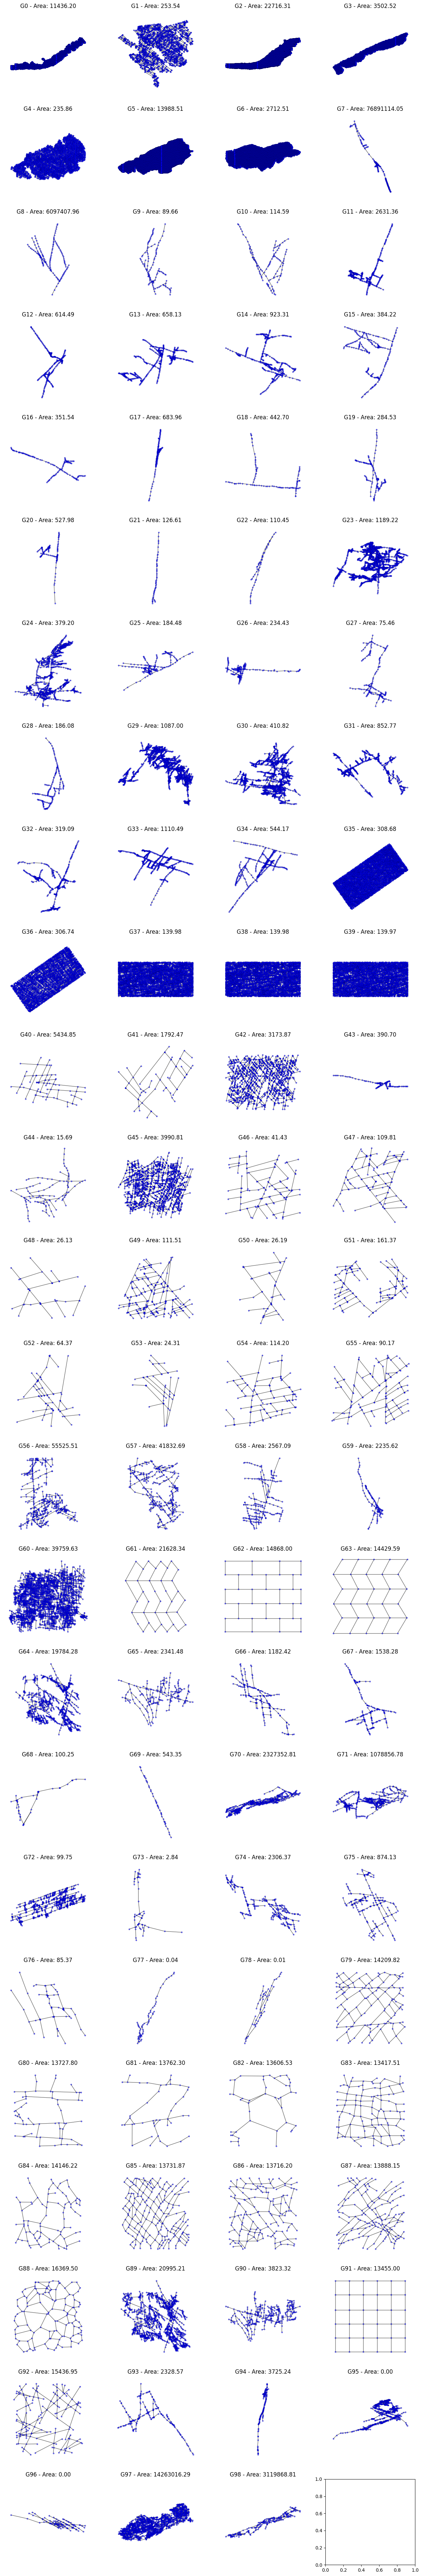

In [7]:
# Plot the fracture network as graphs
kwds = {
    'with_labels': False, 
    'node_shape': 'o',         # node symbol
    'node_color': 'blue',      # node color
    'edgecolors': 'black',     # node border color
    'node_size': 10,            # node size
    'linewidths': 0.2,         # node border width
    'edge_color': 'black',     # edge color
    'width': 1,                # edge width
    'font_size': 8,            # font size
    'font_color': 'black',      # font color
    'alpha': 0.6 ,              # transparency
}

cols = 4
rows = (len(largest) + cols -1) // cols
figsize = (4*cols, 4*rows)

fig, axes = plt.subplots(rows, cols, figsize=figsize)
axes = axes.flatten()

for i, G in enumerate(largest):
    ax = axes[i]
    plt.sca(ax)

    pos = nx.get_node_attributes(G, 'pos')

    if pos:
        nx.draw(G, pos=pos, **kwds)
        area = graph_area(G)
        ax.set_title(f'G{i} - Area: {area:.2f}')
        ax.axis('equal')
    else:
        (f'G{i} (no pos)')
        ax.axis('off')

#plt.savefig('fracgraphsTDS.png', transparent=True, dpi=300)
    
plt.show()

In [ ]:
# Simplify graphs with karstnet
import karstnet as kn
simple = []

for graph in largest:
    print(f'Largest Connected Component: {graph}')
    graphk = kn.from_nxGraph(graph, dict(graph.nodes('pos')), verbose=True)
    K = graphk.graph_simpl
    print(f'Simple graph: {K}')
    nx.set_node_attributes(K, graphk.pos2d, 'pos')
    simple.append(K)

Largest Connected Component: Graph with 28122 nodes and 39314 edges

 This network contains  1  connected components

Simple graph: Graph with 28122 nodes and 39314 edges
Largest Connected Component: Graph with 2177 nodes and 2987 edges

 This network contains  1  connected components

Simple graph: Graph with 2177 nodes and 2987 edges
Largest Connected Component: Graph with 228653 nodes and 364699 edges

 This network contains  1  connected components


In [ ]:
#Export graph as pickle with attributes
for i, graph in enumerate(simple):
    output = f'data/tds_cc_simple/G{i}.pickle'
    with open (output, 'wb') as f:
        pickle.dump(graph, f)

In [ ]:
# Plot the fracture network as graphs
kwds = {
    'with_labels': False, 
    'node_shape': 'o',         # node symbol
    'node_color': 'blue',      # node color
    'edgecolors': 'black',     # node border color
    'node_size': 10,            # node size
    'linewidths': 0.2,         # node border width
    'edge_color': 'black',     # edge color
    'width': 1,                # edge width
    'font_size': 8,            # font size
    'font_color': 'black',      # font color
    'alpha': 0.6 ,              # transparency
}

cols = 4
rows = (len(simple) + cols -1) // cols
figsize = (4*cols, 4*rows)

fig, axes = plt.subplots(rows, cols, figsize=figsize)
axes = axes.flatten()

for i, G in enumerate(simple):
    ax = axes[i]
    plt.sca(ax)

    pos = nx.get_node_attributes(G, 'pos')

    if pos:
        nx.draw(G, pos=pos, **kwds)
        area = graph_area(G)
        ax.set_title(f'G{i} - Area: {area:.2f}')
        ax.axis('equal')
    else:
        (f'G{i} (no pos)')
        ax.axis('off')

#plt.savefig('fracgraphsTDS.png', transparent=True, dpi=300)
    
plt.show()

In [ ]:
import math
# Calculate lengths from graph edges
def lengths(graph):
    pos = nx.get_node_attributes(graph, 'pos')

    for u, v in graph.edges():
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        
        length = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
        graph[u][v]['length'] = round(length, 3)

In [ ]:
# Calculate azimuths from graph edges
def azimuths(graph):
    pos = nx.get_node_attributes(graph, 'pos')
    for u, v in graph.edges():
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        
        # Calculate the angle between the edge and the positive y-axis
        angle_radians = math.atan2(x2 - x1, y2 - y1)
        graph[u][v]['rad'] = round(angle_radians, 2)
        
        angle_degrees = math.degrees(angle_radians)
        azimuth = (angle_degrees + 360) % 360
        graph[u][v]['azimuth'] = round(azimuth, 2)    

In [ ]:
# Define sets from azimuth
def sets(azimuth):
    if (0 <= azimuth < 15) or (165 <= azimuth <= 180):
        return 'NS'
    elif 15 <= azimuth < 30:
        return 'NNE-SSW'
    elif 30 <= azimuth < 45:
        return 'NE-SW'
    elif 45 <= azimuth < 60:
        return 'NE-SW'
    elif 60 <= azimuth < 75:
        return 'ENE-WSW'
    elif 75 <= azimuth < 90:
        return 'E-W'
    elif 90 <= azimuth < 105:
        return 'E-W'
    elif 105 <= azimuth < 120:
        return 'ESE-WNW'
    elif 120 <= azimuth < 135:
        return 'SE-NW'
    elif 135 <= azimuth < 150:
        return 'SE-NWW'
    elif 150 <= azimuth < 165:
        return 'SSE-NNW'
    else:
        return 'Undefined'

In [ ]:
for graph in largest:
    lengths(graph)
    azimuths(graph)

In [ ]:
# Assign family labels to edges based on the set definition
for graph in largest:
    for u, v, data in graph.edges(data=True):
        azimuth = data['azimuth']
        if azimuth > 180:
            azimuth = azimuth -180
        family = sets(azimuth)
        data['family'] = family

In [ ]:
#Export graph as pickle with attributes
for i, graph in enumerate(largest):
    output = f'data/tds_simple_cc_att/G{i}.pickle'
    with open (output, 'wb') as f:
        pickle.dump(graph, f)